# Linear regression

*Leandro Mineti*

*Last edit: March 2020*

## Introduction

We want to model a linear relationship between the features $X$ and a scalar target variable $Y$. Before diving into the math, if you want to get an intuition on how linear regression works, check out [Luis Serrano's explanation](https://www.youtube.com/watch?v=wYPUhge9w5c) [1]. 

In [0]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(51)  # Set seed for reproducibility

# Parameters
real_beta_0 = 2
real_beta_1 = 3
real_sigma2 = 1

# Sample size
n = 100

# Generate data
x = np.linspace(0,5,n)
y = real_beta_0 + real_beta_1*x + real_sigma2 * np.random.randn(n)

## Simple linear regression

We want to model Y given x.

$$Y= \beta_0 + \beta_1x + \epsilon$$

Where is $\epsilon$ is a random variable $\epsilon \sim Normal(0, \sigma^2)$. $Y$ also becomes a random variable, as it is defined in terms of $\epsilon$. We can derive the expected value and variance for Y as follows: 

$$Y|x = \beta_0 + \beta_1x + \epsilon$$

Expected value:

$$
\begin{align}
E(Y|x) &= E(\beta_0 + \beta_1x + \epsilon) \\
E(Y|x) &= E(\beta_0 + \beta_1x) + E(\epsilon) \\
E(Y|x) &= \beta_0 + \beta_1x 
\end{align}
$$

Variance:

$$
\begin{align}
V(Y|x) &= V(\beta_0 + \beta_1x + \epsilon) \\
V(Y|x) &= V(\epsilon) \\
V(Y|x) &= \sigma^2
\end{align}
$$

It is important to note that the variance of $Y$ is fixed of every $x$. This is also known as homogeneity of variance or [homoscedasticity](https://en.wikipedia.org/wiki/Homoscedasticity) [2].

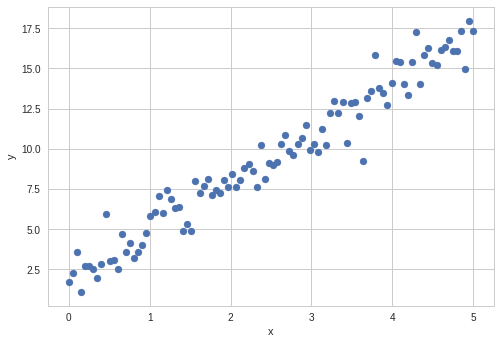

In [0]:
# Plot data
sns.set_style("whitegrid")
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y');

### Parameter estimation

Consider we have a sample of observations pairs $(x_i, y_i)$. For a sample of size $n : \{(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)\}$ we can define:

$$Y_i|x_i = \beta_0 + \beta_1x_i + \epsilon_i$$

for $i = 1, 2, ..., n$.  We can perform inference on the parameters $\beta_0$ and $\beta_1$ using the least squares estimator. First, let's define the error metric as the [Residual Sum of Squares](https://en.wikipedia.org/wiki/Residual_sum_of_squares) [3]: 

$$
\begin{align}
RSS(\beta_0, \beta_1) &= \sum_{i = 1}^{n}[y_i - (\beta_0 + \beta_1x_i)]^2 \\
RSS(\beta_0, \beta_1) &= \sum_{i = 1}^{n}(y_i - \beta_0 - \beta_1x_i)^2
\end{align}
$$

In order to find the estimators $\hat{\beta_0}$ and $\hat{\beta_1}$ for the parameters $\beta_0$ and $\beta_1$ we can minimize the above function:

$$\hat{\beta_0}, \hat{\beta_1} = \underset{\beta_0, \beta_1}{\text{argmin}} \sum_{i = 1}^{n}(y_i - \beta_0 - \beta_1x_i)^2$$

We can solve this equation by calculating the derivative with respect to each parameter and setting it equal to zero. For $\beta_0$ we have: 

$$
\begin{align}
\frac{\partial RSS(\beta_0, \beta_1)}{\partial \beta_0} &= -2\sum_{i = 1}^{n}(y_i - \hat{\beta_0} - \hat{\beta_1}x_i) \\
-2\sum_{i = 1}^{n}(y_i - \hat{\beta_0} - \hat{\beta_1}x_i) &= 0 \\
\sum_{i=1}^{n}y_i - \sum_{i=1}^{n}\hat{\beta_0} - \sum_{i=1}^{n}\hat{\beta_1}x_i &= 0 \\
-n\hat{\beta_0} - \hat{\beta_1}\sum_{i=1}^{n}x_i &= -\sum_{i=1}^{n}y_i \\
n\hat{\beta_0} + \hat{\beta_1}n\bar{x} &= n\bar{y}
\end{align}
$$

where $\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i$ and $\bar{y} = \frac{1}{n}\sum_{i=1}^{n}y_i$. Similarly, for $\beta_1$:

$$
\begin{align}
\frac{\partial RSS(\beta_0, \beta_1)}{\partial \beta_1} &= -2\sum_{i = 1}^{n}(y_i - \hat{\beta_0} - \hat{\beta_1}x_i)x_i \\
-2\sum_{i = 1}^{n}(y_i - \hat{\beta_0} - \hat{\beta_1}x_i)x_i &= 0 \\
\sum_{i=1}^{n}y_i x_i  - \sum_{i=1}^{n}\hat{\beta_0}x_i - \sum_{i=1}^{n} \hat{\beta_1}x_i^2 &= 0 \\
-\hat{\beta_0}\sum_{i=1}^{n}x_i - \hat{\beta_1}\sum_{i=1}^{n}x_i^2 &= - \sum_{i=1}^{n}y_i x_i \\
\hat{\beta_0}n\bar{x}+\hat{\beta_1}\sum_{i=1}^{n}x_i^2 &= \sum_{i=1}^{n}y_i x_i
\end{align}
$$

Usign the two formulas derived, we can form a system of linear equations:

$$
\begin{cases}
\begin{alignat*}{4} 
n\hat{\beta_0} & {}+{} &  n\bar{x}\hat{\beta_1} & {}={} & n\bar{y} \\
n \bar{x}\hat{\beta_0} & {}+{} & \sum_{i=1}^{n}x_i^2\hat{\beta_1} & {}={} &  \sum_{i=1}^{n}y_i x_i 
\end{alignat*}
\end{cases}
$$

Solving the system, we obtain:

$$
\begin{align}
\hat{\beta_0} &= \bar{y}-\hat{\beta_1}\bar{x} \\
\hat{\beta_1} &= \frac{\sum_{i=1}^{n}y_i(x_i-\bar{x})}{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\end{align}
$$

Using these equations we can estimate the parameters for the data we generated.

In [0]:
beta_1 = np.sum(y*(x-np.mean(x)))/np.sum((x-np.mean(x))**2)

beta_0 = np.mean(y) - beta_1*np.mean(x)

'The estimated coefficients beta_0 and beta_1 are {} and {}, respectively'.format(np.round(beta_0, 3), np.round(beta_1, 3))

'The estimated coefficients beta_0 and beta_1 are 1.925 and 3.028, respectively'

The estimators seem close to the actual value. Other approach is to solve this optimization problem with other algorthms, e.g. [gradient descent](https://en.wikipedia.org/wiki/Gradient_descent) [4].

In [0]:
from scipy.optimize import minimize

def rss(beta, x, y):
  return (np.sum((y - beta[0] - beta[1]*x)**2))

beta_0, beta_1 = minimize(rss, [0, 0], args = (x,y)).x

'The estimated coefficients beta_0 and beta_1 are {} and {}, respectively'.format(np.round(beta_0, 3), np.round(beta_1, 3))

'The estimated coefficients beta_0 and beta_1 are 1.925 and 3.028, respectively'

We got very similar results using a different technique. Now, let's plot the results to check if we got a reasonable linear model.

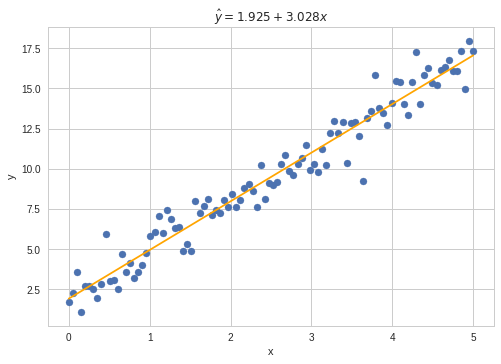

In [0]:
y_hat = beta_0 + beta_1*x

plt.scatter(x, y)
plt.plot(x, y_hat, color = 'orange')
plt.xlabel('x')
plt.ylabel('y')
plt.title("$\hat{y} = 1.925 + 3.028x$");

### Properties of the estimators

As the estimators $\hat{\beta_0}$ and $\hat{\beta_1}$are random variables, we can explore its expected value and variance. 

#### Expected value and variance of $\hat{\beta_1}$

$$
\begin{align}
\hat{\beta_1} &= \sum_{i = 1}^{n} [\frac{(x_i-\bar{x})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}]Y_i = \sum_{i=1}^{n}c_iY_i \\
E(\hat{\beta_1}) &= E(\sum_{i=1}^{n}c_i Y_i) = \sum_{i=1}^{n}c_iE(Y_i) \\
E(\hat{\beta_1}) &= \sum_{i=1}^{n}c_i(\beta_0 + \beta_1 x_i) \\
E(\hat{\beta_1}) &= \beta_0\sum_{i=1}^{n}c_i + \beta_1 \sum_{i=1}^{n}c_i x_i 
\end{align}
$$

where:

$$\sum_{i=1}^{n}c_i = \frac{\sum_{i=1}^{n}(x_i - \bar{x})}{\sum_{i=1}^{n}(x_i - \bar{x})^2} = 0$$

As $\sum_{i=1}^{n}c_i  = 0$, we have:

$$E(\hat{\beta_1}) = \beta_1 \sum_{i=1}^{n}c_i x_i$$

where:

$$
\begin{align}
\sum_{i=1}^{n}c_i x_i &= \frac{\sum_{i=1}^{n}x_i(x_i - \bar{x})}{\sum_{i=1}^{n}(x_i-\bar{x})^2} \\
\sum_{i=1}^{n}c_i x_i &= \frac{\sum_{i=1}^{n}x_i^2 - \sum_{i=1}^{n}x_i\bar{x}}{\sum_{i=1}^{n}(x_i^2-2x_i\bar{x}+\bar{x}^2)} \\
\sum_{i=1}^{n}c_i x_i &= \frac{\sum_{i=1}^{n}x_i^2 - \bar{x}\sum_{i=1}^{n}x_i}{\sum_{i=1}^{n}x_i^2 - 2\bar{x}\sum_{i=1}^{n}x_i + n\bar{x}^2} \\
\sum_{i=1}^{n}c_i x_i &= \frac{\sum_{i=1}^{n}x_i^2 - n\bar{x}^2}{\sum_{i=1}^{n}x_i^2 - 2n\bar{x}^2 + n\bar{x}^2} \\
\sum_{i=1}^{n}c_i x_i &= \frac{\sum_{i=1}^{n}x_i^2 - n\bar{x}^2}{\sum_{i=1}^{n}x_i^2 - n\bar{x}^2} = 1 
\end{align}
$$

So, we have:

$$E(\hat{\beta_1}) = \beta_1$$

For the variance, considering $V(Y_i) = \sigma^2$, we have:

$$
\begin{align}
V(\hat{\beta_1}) &= V(\sum_{i=1}^{n}c_iY_i) = \sum_{i=1}^{n}c_i^2V(Y_i) \\
V(\hat{\beta_1}) &= \frac{\sigma_2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}
\end{align}
$$.

In practice, we usually do not have access to the real value of $\sigma^2$. In that case, we can substitute it for the estimator $\hat{\sigma^2} = \frac{\sum_{i=1}^{n}(y_i - \hat{y})^2}{n-2}$. In order to validate the mean and variance we calculated, we can estimate $\beta_1$ for a hundred different samples and visualize the distribution of the estimated values.

In [0]:
b1_sigma2 = real_sigma2/np.sum((x - np.mean(x))**2)

'The estimated variance for beta_1 is {}.'.format(np.round(b1_sigma2, 5))

'The estimated variance for beta_1 is 0.0047.'

In [0]:
np.random.seed(51)

y_100 = real_beta_0 + real_beta_1*x + real_sigma2 * np.random.randn(100, n)

# Estimating beta_1 for each sample
b1 = [minimize(rss, [0, 0], args = (x, i)).x[1] for i in y_100]

/usr/local/lib/python3.6/dist-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")


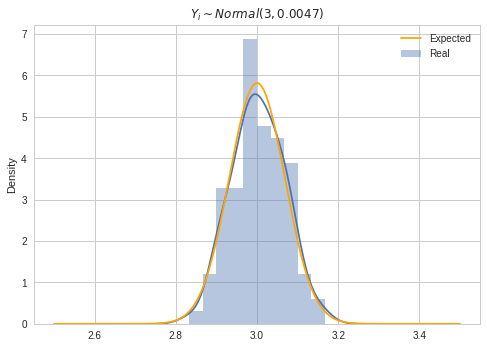

In [0]:
exp_x = np.linspace(2.5,3.5,1000)
exp_b1 = norm.pdf(exp_x, loc=3, scale = np.sqrt(b1_sigma2))  

sns.distplot(b1, norm_hist = True)
plt.plot(exp_x, exp_b1, color = 'orange')
plt.ylabel('Density')
plt.legend(('Expected', 'Real'), loc='upper right')
plt.title("$Y_i \sim Normal (3, 0.0047)$")
plt.show();

#### Expected value and variance of $\hat{\beta_0}$

We can apply the same approach to $\beta_0$:

$$
\begin{align}
E(\hat{\beta_0}) &= E(\bar{y} - \hat{\beta_1}\beta{x}) = E(\bar{y}) - E(\hat{\beta_1}\bar{x}) \\
E(\hat{\beta_0}) &= \frac{1}{n}\sum_{i=1}^{n}y_i - \bar{x}\beta_1 = \frac{1}{n}(\sum_{i=1}^{n}\beta_0 + \beta_1x_i) - \bar{x}\beta_1 \\
E(\hat{\beta_0}) &= \beta_0 + \frac{1}{n}\beta_1\sum_{i=1}^{n}x_i -\bar{x}\beta_1 = \beta_0 + \beta_1\bar{x} - \beta_1\bar{x} \\
E(\hat{\beta_0}) &= \beta_0
\end{align}
$$

For the variance, considering $V(Y_i) = \sigma^2$, we have:

$$
\begin{align}
V(\hat{\beta_0}) &= V(\bar{Y} - \hat{\beta_1}\bar{x}) \\
V(\hat{\beta_0}) &= V(\bar{Y}) + \bar{x}^2V(\hat{\beta_1}) -2\bar{x}Cov(\bar{Y}, \hat{\beta_1})
\end{align}
$$

where $V(\bar{Y}) = \frac{\sigma^2}{n}$ and $Cov(\bar{Y}, \hat{\beta_1}) = 0$. Than, we have:

$$
\begin{align}
V(\hat{\beta_0}) &= V(\bar{Y}) + \bar{x}^2V(\hat{\beta_1}) \\
V(\hat{\beta_0}) &= \sigma^2(\frac{1}{n}+\frac{\bar{x}^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2})
\end{align}
$$.

In [0]:
# Calculating the variance for the beta0 estimator
b0_sigma2 = ((1/n) + (np.mean(x)**2)/np.sum((x - np.mean(x))**2))*real_sigma2

'The estimated variance for beta_0 is {}.'.format(np.round(b0_sigma2, 5))

'The estimated variance for beta_0 is 0.03941.'

Again, similar to what we did for $\beta_1$, we can estimate $\beta_0$ for a hundrd different samples and visualize the distribution of the estimated values.

In [0]:
# Estimating beta_0 for each sample
b0 = [minimize(rss, [0, 0], args = (x, i)).x[0] for i in y_100]

/usr/local/lib/python3.6/dist-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")


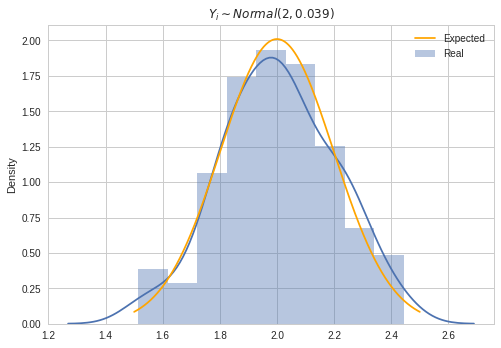

In [0]:
exp_x = np.linspace(1.5,2.5,1000)
exp_b1 = norm.pdf(exp_x, loc=2, scale = np.sqrt(b0_sigma2))  

sns.distplot(b0, norm_hist = True)
plt.plot(exp_x, exp_b1, color = 'orange')
plt.ylabel('Density')
plt.legend(('Expected', 'Real'), loc='upper right')
plt.title("$Y_i \sim Normal (2, 0.039)$")
plt.show();

### Confidence interval for the target

As $\beta_0$ and $\beta_1$ are random variables, their combination when defining the mean $\hat{\mu_Y}|x$ is a random variable too. As a random variable, we can define its expected value and variance.

$$
\begin{align}
\hat{\mu}_{Y|x_0} &= \hat{E}(Y|x_0) \\
\hat{\mu}_{Y|x_0} &= \hat{\beta}_0 +\hat{\beta}_1 x_0
\end{align}
$$

For the expected value, we have:

$$
\begin{align}
E(\hat{\mu}_{Y|x_0}) &= E( \hat{\beta}_0 +\hat{\beta}_1 x_0 ) \\
E(\hat{\mu}_{Y|x_0}) &= E( \hat{\beta}_0 ) + E(\hat{\beta}_1 )x_0 \\
E(\hat{\mu}_{Y|x_0}) &= \beta_0 + \beta_1x_0 
\end{align}
$$

and for the variance:
                          
$$
\begin{align}
V(\hat{\mu}_{Y|x_0}) &= V(\hat{\beta}_0 +\hat{\beta}_1 x_0) \\
V(\hat{\mu}_{Y|x_0}) &= V[\bar{y}+\hat{\beta}_1 (x_0-\bar{x})]
\end{align}
$$

where $Cov(\bar{y}, \hat{\beta_1}) = 0$, so:

$$
\begin{align}
V(\hat{\mu}_{Y|x_0}) &= \frac{\sigma^2}{n} + \sigma^2\frac{(x_0-\bar{x}^2)^2}{\sum_{i=1}^{n}(x_i-\bar{x})^2} \\
V(\hat{\mu}_{Y|x_0}) &= \sigma^2[\frac{1}{n}+\frac{(x_0-\bar{x})^2}{\sum_{i=1}^{n}(x_i-\bar{x})^2}]
\end{align}
$$

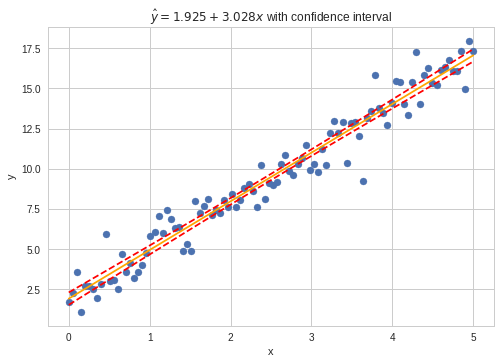

In [0]:
y_hat_var = (np.sum((y - y_hat)**2)/(n-2))*((1/n) + ((x - np.mean(x))**2)/np.sum((x - np.mean(x))**2))

y_hat = beta_0 + beta_1*x

y_hat_upper = y_hat + 1.96*np.sqrt(y_hat_var)
y_hat_lower = y_hat - 1.96*np.sqrt(y_hat_var)

plt.scatter(x, y)
plt.plot(x, y_hat, color = 'orange')
plt.xlabel('x')
plt.ylabel('y')
plt.title("$\hat{y} = 1.925 + 3.028x$ with confidence interval")
plt.plot(x, y_hat_upper, color = 'red', ls = 'dashed')
plt.plot(x, y_hat_lower, color = 'red', ls = 'dashed');

The confidence lines are not parallel! Why is that? By checking the definition of $V(\hat{\mu}_{Y|x_0}) $ we can see that it depends on the value of $x_0$. 

### Coefficient of determination

The coefficient of determination (R2) represents the percentage of variance of the target explained by the feature. As a percentage, the values of R2 must be between 0 and 1.

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y})^2}{\sum_{i=1}^{n}(y_i- \bar{y})^2}$$

In [0]:
# Calculating the coefficient of determination
r2 = 1 - (np.sum((y - y_hat)**2)/np.sum((y - np.mean(y))**2))

'The coefficient of correlation (R2) for the example is {}.'.format(np.round(r2, 2))

'The coefficient of correlation (R2) for the example is 0.95.'

### Interpretation

A change of 1 on the predictor has a change of $\beta_1$ at the target. When the predictor is 0 the mean is $\beta_0$

## Conclusion

The linear regression is a standard first candidate when solving a regression problem. Besides, it is a good choice when you want to understand how each predictor affects the target variable. If you want to check how to performe linear regression when you have more than one feature, please check out the [multiple linear regression](https://colab.research.google.com/drive/1DMmQ_aVQhRZ7bwIgFFSElCxgTpWCt74f) notebook.

## References

[1] Luis Serrano. (n.d.). A Friendly Introduction to Linear Regression. Retrieved from https://www.youtube.com/watch?v=wYPUhge9w5c

[2] Homoscedasticity. (2018). In Wikipedia. Retrieved from https://en.wikipedia.org/w/index.php?title=Homoscedasticity&oldid=824505667

[3] Residual sum of squares. (2018). In Wikipedia. Retrieved from https://en.wikipedia.org/w/index.php?title=Residual_sum_of_squares&oldid=872962956

[4] Gradient descent. (2019). In Wikipedia. Retrieved from https://en.wikipedia.org/w/index.php?title=Gradient_descent&oldid=876425779

[5] Costa, M. A. (2019). Tópicos em ciência dos dados: Introdução aos modelos paramétricos e seus aplicações utilizando o R. Bonecker.

[6] Montgomery, D. C., Peck, E. A., & Vining, G. G. (2012). Introduction to linear regression analysis (Vol. 821). John Wiley & Sons.